**Key features:**
- Apply Gaussian smoothing to address data noise and sparsity
- Construct a gene co-expression network across samples using smoothed dataset
- Group genes into spatial modules with hard and soft thresholding on the co-expression network

In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings() # Suppress a few warnings for cleaner output

### **Load AnnData**

**Smoothie requires data input in the AnnData format.** A guide for constructing the AnnData data structure for both imaging-based and sequencing-based spatial transcriptomics outputs can be found in `/guides/convert_to_anndata.md` 

In [11]:
# Load your spatial transcriptomics data 
# Data source (all_bin_levels.gz): https://www.10xgenomics.com/datasets/visium-hd-three-prime-ovarian-cancer-fresh-frozen
adata = sc.read_10x_mtx("/path/to/binned_outputs/square_002um/filtered_feature_bc_matrix/")
coords = pd.read_parquet("/path/to/binned_outputs/square_002um/spatial/tissue_positions.parquet")

# Ensure barcode column is string (important!)
coords['barcode'] = coords['barcode'].astype(str)
adata.obs_names = adata.obs_names.astype(str)

# Set barcode as index
coords_indexed = coords.set_index('barcode')

# Reindex to match AnnData order
coords_matched = coords_indexed.loc[adata.obs_names]

# Sanity check
assert np.all(coords_matched.index == adata.obs_names)

# Copy spatial coordinates
adata.obsm["spatial"] = coords_matched[
    ["pxl_col_in_fullres", "pxl_row_in_fullres"]
].values

# adata = ad.read_h5ad("/path/to/adata.h5ad")

In [12]:
adata

AnnData object with n_obs × n_vars = 7186414 × 38606
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'

### **Quality Control**

| Resolution | `min_counts (filter_cells)` | `min_counts (filter_genes)` | `min_cells (filter_genes)` |
| :--- | :--- | :--- | :--- |
| **"Cell-sized" (8-10 µm)** | 10 - 100 | 100 - 500 | 10 - 100 |
| **Binned (20-50 µm)** | 50 - 500 | 100 - 500 | 10 - 100 |
| **Fine / Imaging (< 1-2 µm)** | 1 | 100 - 500 | 10 - 100 |

In [13]:
# Filter spots with low UMI counts
sc.pp.filter_cells(adata, min_counts=1)

# Filter genes with low counts/unique spots
sc.pp.filter_genes(adata, min_cells=50)

In [14]:
adata

AnnData object with n_obs × n_vars = 6443922 × 16707
    obs: 'n_counts'
    var: 'gene_ids', 'feature_types', 'n_cells'
    obsm: 'spatial'

### **Normalization**

| **Resolution** | Normalization Method |
| :--- | :--- |
| **"Cell sized" or Binned Data (8-50 micron resolution)** | CPT + Log1p normalization |
| **Fine / Imaging (<1-2 micron resolution)** | Log1p normalization only |

In [15]:
# # CHOOSE: CPT + Log1p normalization (8-50 micron resolution data)
# sc.pp.normalize_total(adata, target_sum=1e3)
# sc.pp.log1p(adata)

# CHOOSE: Log1p normalization only (<1-2 micron resolution data)
sc.pp.log1p(adata)

### **Step 1: Run Gaussian Smoothing**

Here, we run Gaussian smoothing on the spatial dataset address data sparsity and noise. Key parameters for function *smoothie.run_parallelized_smoothing*:

**gaussian_sd: float**
- The standard deviation for the Gaussian distribution, which determines smoothing degree. Generally across high-resolution S.T. platforms, a gaussian_sd corresponding to 20-30 microns is ideal. 
- **gaussian_sd** is calculated as target_microns * micron_to_unit_conversion
  - For Slide-seq, micron_to_unit_conversion = 1.5456 (1 micron equals 1.5456 Slide-seq spatial units)
  - For Stereo-seq, micron_to_unit_conversion = 2 (1 micron equals 2 Stereo-seq spatial units)
  - A table of micron_to_unit_conversion values for spatial transcriptomics platforms is included in `/guides/micron_to_unit_conversion_table.md`

**grid_based_or_not: boolean**
- **True** = grid-based smoothing: smooth only at imposed hexagonal grid points. Good for subcellular to "cell-sized" resolution data (<1-10 micron).
- **False** = in-place smoothing: smooth at every spatial location in the dataset. Good for "cell-sized" to binned resolution data (10-50 micron).

**min_spots_under_gaussian**
- Minimum required number of data points within radius (3 * gaussian_sd) for smoothing to occur at a given location.
- Default is 10-100. Raise value if low density regions around the perimeter of tissue appear noisy in modules. Lower value if you have large spot size (e.g. original Visium 100 micron resolution data or binned 20-50 micron resolution).

In [16]:
import json

file_path = "/path/to/binned_outputs/square_002um/spatial/scalefactors_json.json"
with open(file_path, "r") as f:
    scalefactors = json.load(f)

microns_per_pixel = scalefactors.get("microns_per_pixel")
print("microns_per_pixel:", microns_per_pixel)

microns_per_pixel: 0.2737061758251425


In [17]:
# Determine gaussian_sd ---------------------------------------------------
target_microns = 20.0 # 20-30 microns is ideal for smoothing
micron_to_unit_conversion = (1.0 / microns_per_pixel)  # IMPORTANT! Select for your platform
# ------------------------------------------------------------------------

sm_adata = smoothie.run_parallelized_smoothing(
    adata,
    grid_based_or_not=True,  # Select True or False,
    gaussian_sd=target_microns * micron_to_unit_conversion,
    min_spots_under_gaussian=100 # Adjust as needed
)

Checking dataset point density...
Fitting grid to tissue coordinates...
Variation in X-direction: 24449.280967032064
Variation in Y-direction: 24489.385447826324
Number of points in fitted grid: 83447
Gaussian smoothing will run in 36 chunks.
Smoothing chunk: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 
Total runtime for grid-based Gaussian smoothing: 56.46 seconds.



### **Step 2: Measure and Cluster Gene Co-expression Network**

First, we compute the pairwise Pearson correlation coefficient between all smoothed gene surface pairs.

Next, we evaluate optimal hyperparameter choices for network construction and clustering.
The function **smoothie.select_clustering_params** calculates network clustering statistics across different choices for **pcc_cutoff** and **clustering_power**.

Choose values for **pcc_cutoff** and **clustering_power** that balance the following goals:
1) High gene margin scores for high gene module confidence
2) Stable number of modules (n_clusters) compared to other **pcc_cutoff** values
3) High gene recall for more gene-rich analyses

Refer to /docs/tutorials for examples on selecting these parameters.

In [18]:
# Compute pairwise gene correlations
pearsonR_mat, _ = smoothie.compute_correlation_matrix(sm_adata.X)

compute_correlation_matrix running...
Total runtime for compute_correlation_matrix: 432.42 seconds.



Running network clustering with parameters:
PCC hard cutoff: 0.2, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.3, clustering soft power: 1, 5, 7, 9, 
PCC hard cutoff: 0.4, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.5, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.6, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.7, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.8, clustering soft power: 1, 3, 5, 7, 9, 


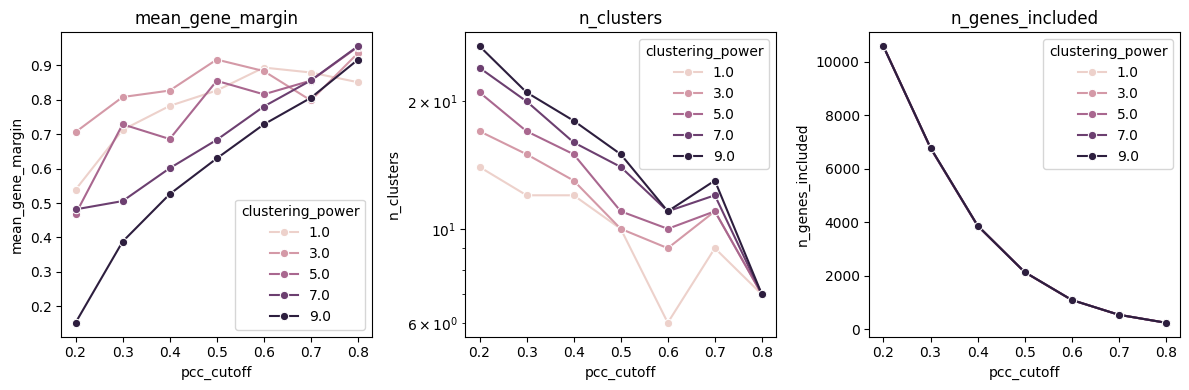

In [19]:
# Clustering hyperparameter selection
smoothie.select_clustering_params(
    gene_names=sm_adata.var_names, # don't change
    pearsonR_mat=pearsonR_mat, # don't change
    output_folder=None,
    pcc_cutoffs=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], # lower pcc_cutoffs require more runtime
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

Optionally, data shuffling and smoothing can be done to help determine the lower bound for pcc_cutoff selection. Here, use the same parameters as before in **smoothie.run_parallelized_smoothing**.

In [ ]:
# p95, p99, p999 = smoothie.compute_shuffled_correlation_percentiles(
#     adata,
#     grid_based_or_not=True, # Choose same value as in smoothie.run_parallelized_smoothing
#     gaussian_sd=target_microns * micron_to_unit_conversion, # Choose same value as in smoothie.run_parallelized_smoothing
#     min_spots_under_gaussian=100, # Choose same value as in smoothie.run_parallelized_smoothing
#     seed=0
# )

Based on the outputs above, we can select **pcc_cutoff** and **clustering_power** hyperparameters for **smoothie.make_spatial_network**.

**pcc_cutoff**: The Pearson correlation coefficient (PCC) hard threshold for network construction. Only correlations above this value are retained in the gene network. Higher cutoff values result in smaller, stronger average correlation networks.

**clustering_power**: A soft thresholding parameter that controls how much weaker PCC values are suppressed. Higher values favor more modules.

In [20]:
edge_list, node_label_df = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=3,
    output_folder='./out'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df = node_label_df.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df

,name,module_label,degree,weighted_degree,rescaled_weighted_degree,clustering_coeff,margin_score
0,RPL41,1,2553,1372.513644,133.901711,0.225792,0.525152
1,EEF1A1,1,2658,1429.879500,133.743191,0.208542,0.189460
2,RPLP1,1,2572,1380.986015,131.029755,0.222512,0.628023
3,RPL27A,1,2560,1374.454137,126.975913,0.224314,0.430980
4,RPS27A,1,2375,1277.583360,124.282868,0.255539,0.124824
...,...,...,...,...,...,...,...
3863,CLDN5,25,1,0.441020,0.000320,0.000000,1.000000
3864,PRG4,26,1,0.421040,0.000043,0.000000,1.000000
3865,CTSE,26,1,0.421040,0.000043,0.000000,1.000000
3866,VOPP1,27,40,16.809996,0.005548,0.987179,-1.000000


Finally, we can import the saved edge_list.csv and node_labels.csv files into **Cytoscape for interactive network visualization!** More info in `/guides/cytoscape_instructions.md`

### **Visualize Smoothed Gene Expression and Modules**

In [ ]:
# Plot individual gene
smoothie.plot_gene(
    sm_adata=sm_adata,
    gene_name="Gene1",  # Replace with your gene
    output_folder="./gene_plots",
    spot_size=25,  # Adjust for optimal visualization
)

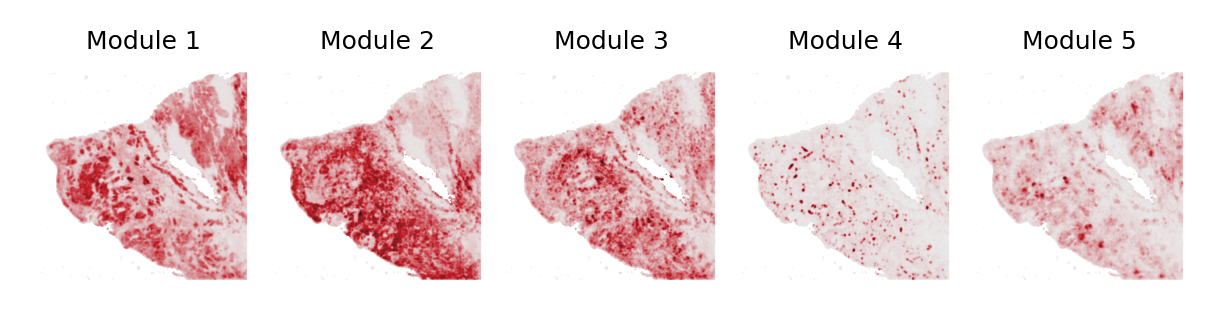

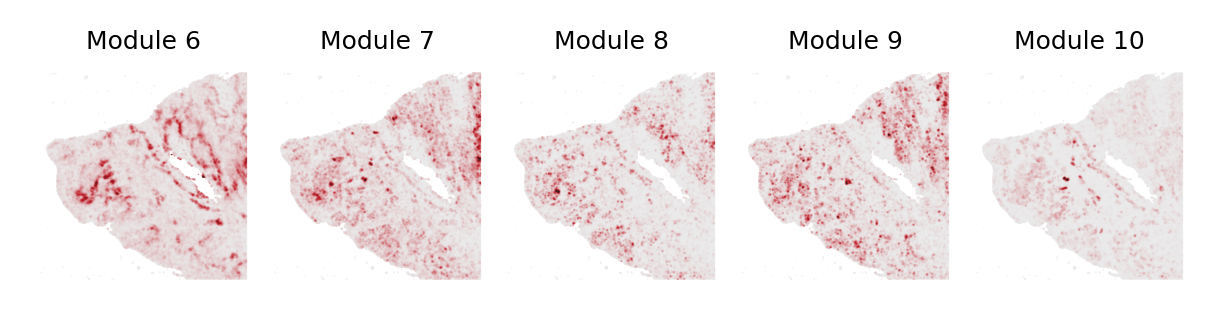

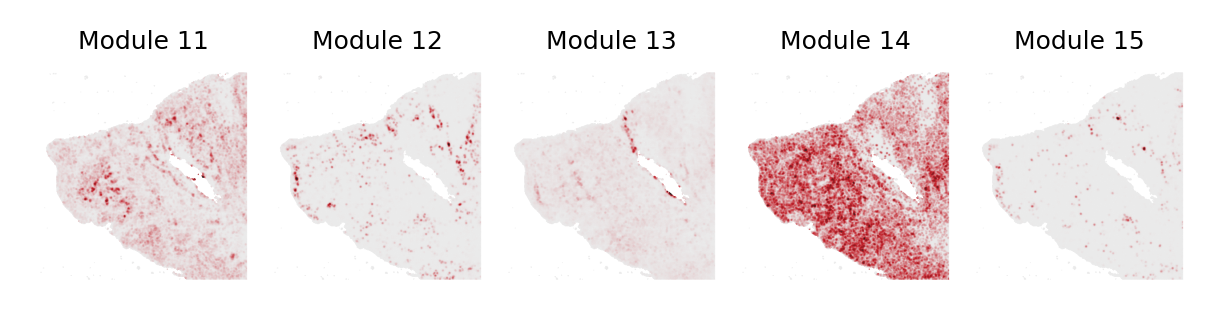

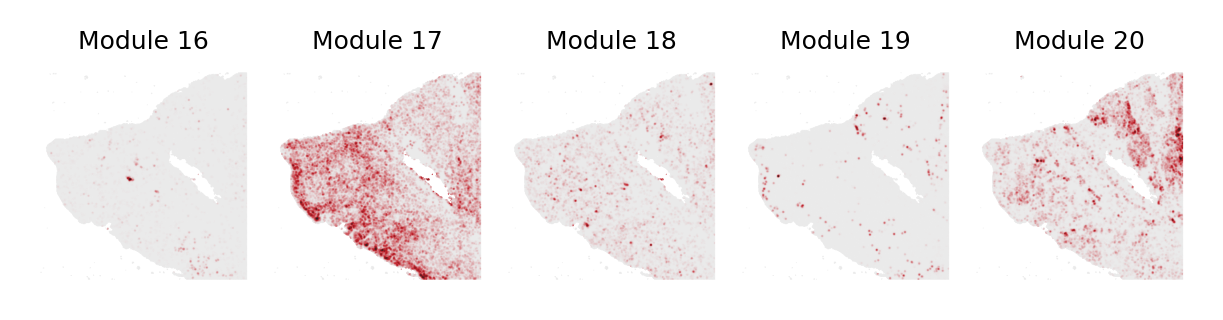

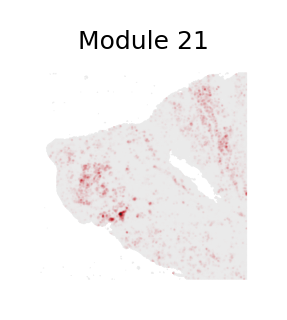

In [23]:
# Plot all gene modules
smoothie.plot_modules(
    sm_adata,
    node_label_df,
    output_folder='./module_plots', 
    min_genes=3, # Minimum number of genes in a module to plot the module
    spot_size=100, # Adjust for optimal visualization
    dpi=150 # low resolution here for github, better to choose 300-600!
)

### **Analyze Specific Gene or Gene Set Correlations**
1) Find top correlated genes to a gene of interest.
2) Build a network focused on a specific set of genes with a more permissive PCC cutoff.

In [ ]:
# Find top correlated genes for a gene of interest (GOI)
GOI_correlations = smoothie.get_correlations_to_GOI(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    GOI="Gene1",
    reverse_order=False,  # False for top correlations, True for anti-correlations
    plot_histogram=True
)
    
print(f"\nTop 10 gene correlations with GOI:")
print(GOI_correlations[:10])

In [ ]:
# Build targeted network for your gene set of interest
my_gene_list = ['Gene1', 'Gene2', 'Gene3']  # Replace with your genes

# Build targeted network
geneset_edge_list, geneset_node_label_df = smoothie.make_geneset_spatial_network(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    node_label_df=node_label_df, # don't change
    gene_list=my_gene_list,
    low_pcc_cutoff=0.3,  # More permissive pcc_cutoff than main network
    output_folder=None,
    intra_geneset_edges_only=True  # Only edges within gene set
)

print(f"Gene set network: {len(geneset_edge_list)} edges")
print(f"Genes included: {geneset_node_label_df['geneset_member'].sum()}")